<a href="https://colab.research.google.com/github/muhammedgmbsg/transfer-learning-classifier/blob/main/deep-learning-fruit-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import os
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

print("Veriler yerel diske taşınıyor...")
!cp -r /content/drive/MyDrive/fruits /content/fruits_raw
!mkdir -p /tmp/fruits_data
!cp -r /content/fruits_raw/* /tmp/fruits_data/
print("Taşıma tamamlandı.")

Veriler yerel diske taşınıyor...
Taşıma tamamlandı. Eğitim şimdi uçuşa geçecek!


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0, ResNet50, VGG16, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
import gc

In [ ]:
DATA_ROOT = '/tmp/fruits_data'
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

In [ ]:
def get_dataset(path):
    file_paths, labels = [], []
    for folder in ['train', 'test']:
        curr = os.path.join(path, folder)
        if not os.path.exists(curr): continue
        classes = sorted([d for d in os.listdir(curr) if os.path.isdir(os.path.join(curr, d))])
        for cls in classes:
            cls_dir = os.path.join(curr, cls)
            for img in os.listdir(cls_dir):
                file_paths.append(os.path.join(cls_dir, img))
                labels.append(cls)
    return pd.DataFrame({'filename': file_paths, 'class': labels}), classes

df, categories = get_dataset(DATA_ROOT)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['class'], random_state=42)

datagen = ImageDataGenerator(rescale=1./255)
train_gen = datagen.flow_from_dataframe(train_df, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True, verbose=0)
val_gen = datagen.flow_from_dataframe(val_df, x_col='filename', y_col='class', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False, verbose=0)

Found 2660 validated image filenames belonging to 10 classes.
Found 666 validated image filenames belonging to 10 classes.




##################################################
# MODEL: MobileNetV2 EĞİTİMİ BAŞLIYOR
##################################################
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 27s 221ms/step - accuracy: 0.4297 - loss: 1.7777 - val_accuracy: 0.6532 - val_loss: 1.1605
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7688 - loss: 0.8627 - val_accuracy: 0.7958 - val_loss: 0.7049
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.8519 - loss: 0.5515 - val_accuracy: 0.8378 - val_loss: 0.5475
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - accuracy: 0.8883 - loss: 0.4136 - val_accuracy: 0.8498 - val_loss: 0.4767
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.9135 - loss: 0.3292 - val_accuracy: 0.8634 - val_loss: 0.4336
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9305 - loss: 0.2721 - val_accuracy: 0.8784 - val_loss: 0.3959
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.9447 - loss: 0.2285 - val_acc

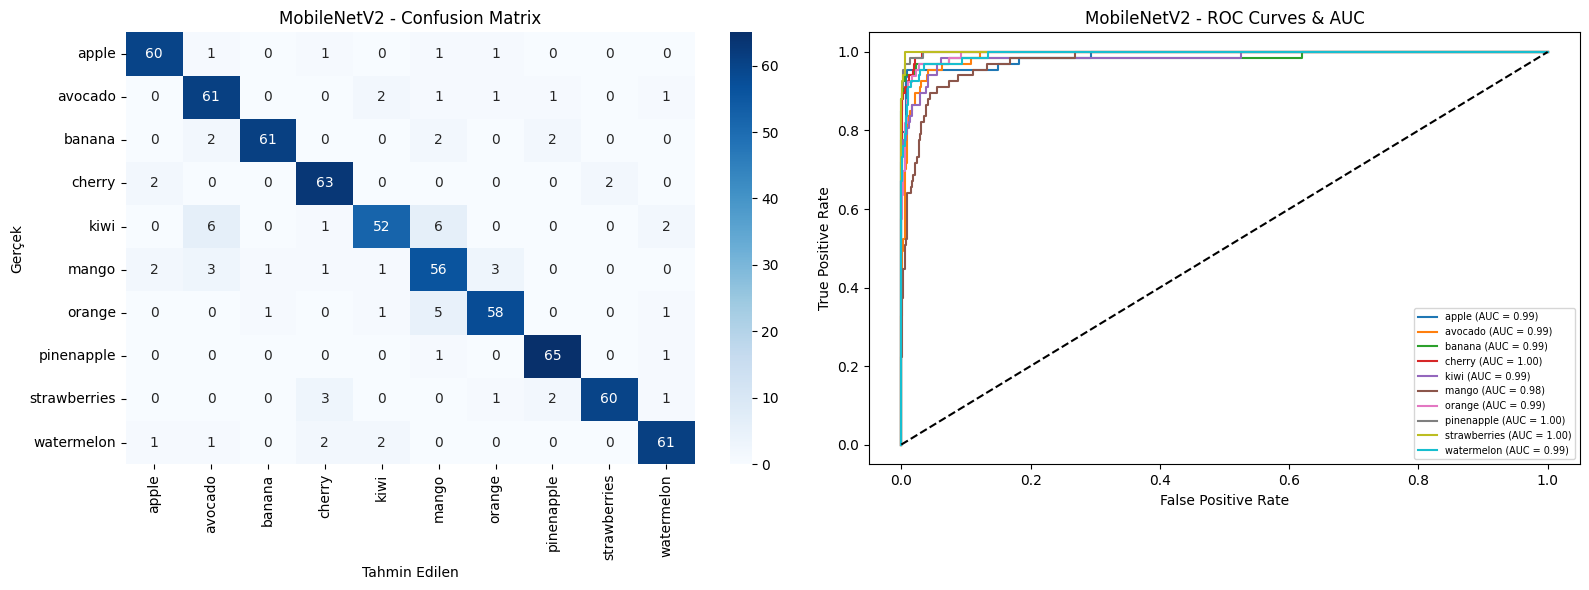


MobileNetV2 Performans Metrikleri:
        Sınıf  Sensitivity  Specificity  F1-Score  Precision
       apple     0.937500     0.991694  0.930233   0.923077
     avocado     0.910448     0.978297  0.865248   0.824324
      banana     0.910448     0.996661  0.938462   0.968254
      cherry     0.940299     0.986644  0.913043   0.887324
        kiwi     0.776119     0.989983  0.832000   0.896552
       mango     0.835821     0.973289  0.805755   0.777778
      orange     0.878788     0.990000  0.892308   0.906250
  pinenapple     0.970149     0.991653  0.948905   0.928571
strawberries     0.895522     0.996661  0.930233   0.967742
  watermelon     0.910448     0.989983  0.910448   0.910448


##################################################
# MODEL: EfficientNetB0 EĞİTİMİ BAŞLIYOR
##################################################
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 46s 296ms/step - accuracy: 0.0985 - loss: 2.3122 - val_accuracy: 0.1006 - val_loss: 2.3046
Epoch 2/10
84/84 ━━━━━━━━━━━━

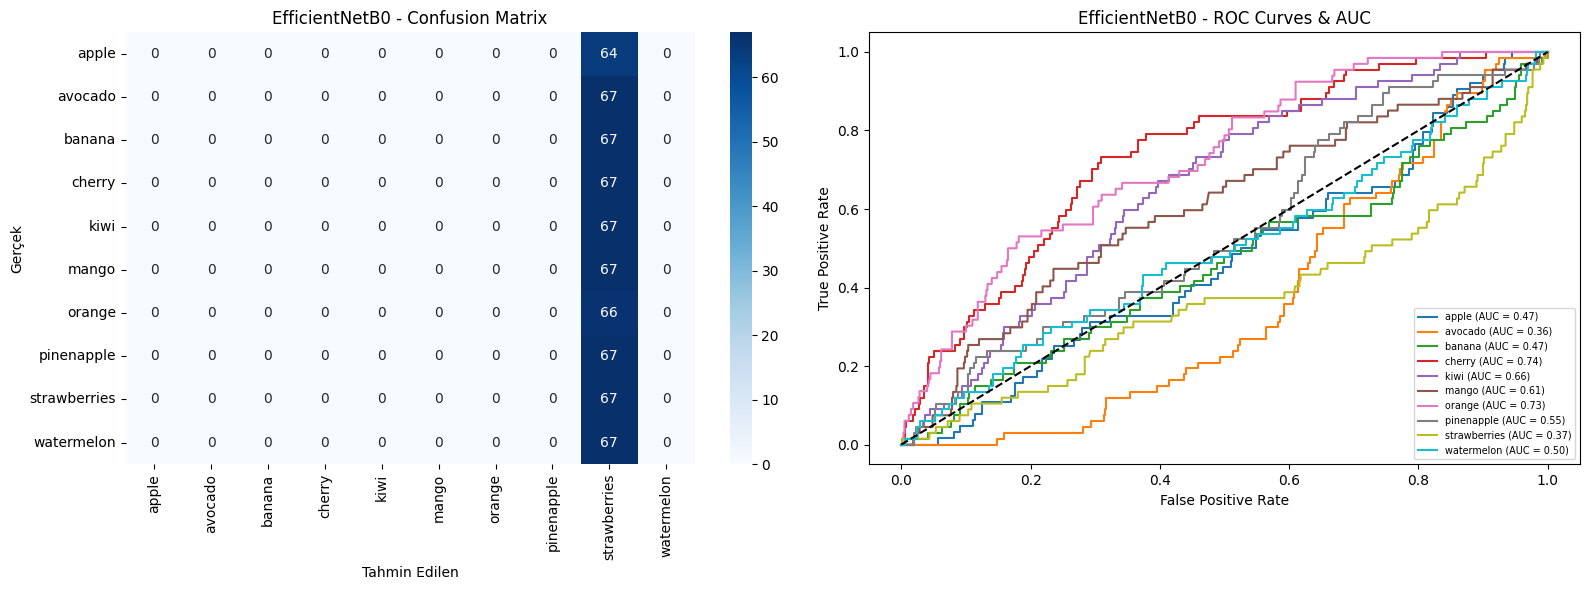


EfficientNetB0 Performans Metrikleri:
        Sınıf  Sensitivity  Specificity  F1-Score  Precision
       apple          0.0          1.0   0.00000   0.000000
     avocado          0.0          1.0   0.00000   0.000000
      banana          0.0          1.0   0.00000   0.000000
      cherry          0.0          1.0   0.00000   0.000000
        kiwi          0.0          1.0   0.00000   0.000000
       mango          0.0          1.0   0.00000   0.000000
      orange          0.0          1.0   0.00000   0.000000
  pinenapple          0.0          1.0   0.00000   0.000000
strawberries          1.0          0.0   0.18281   0.100601
  watermelon          0.0          1.0   0.00000   0.000000


##################################################
# MODEL: ResNet50 EĞİTİMİ BAŞLIYOR
##################################################
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 24s 166ms/step - accuracy: 0.1011 - loss: 2.3502 - val_accuracy: 0.1171 - val_loss: 2.2947
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━

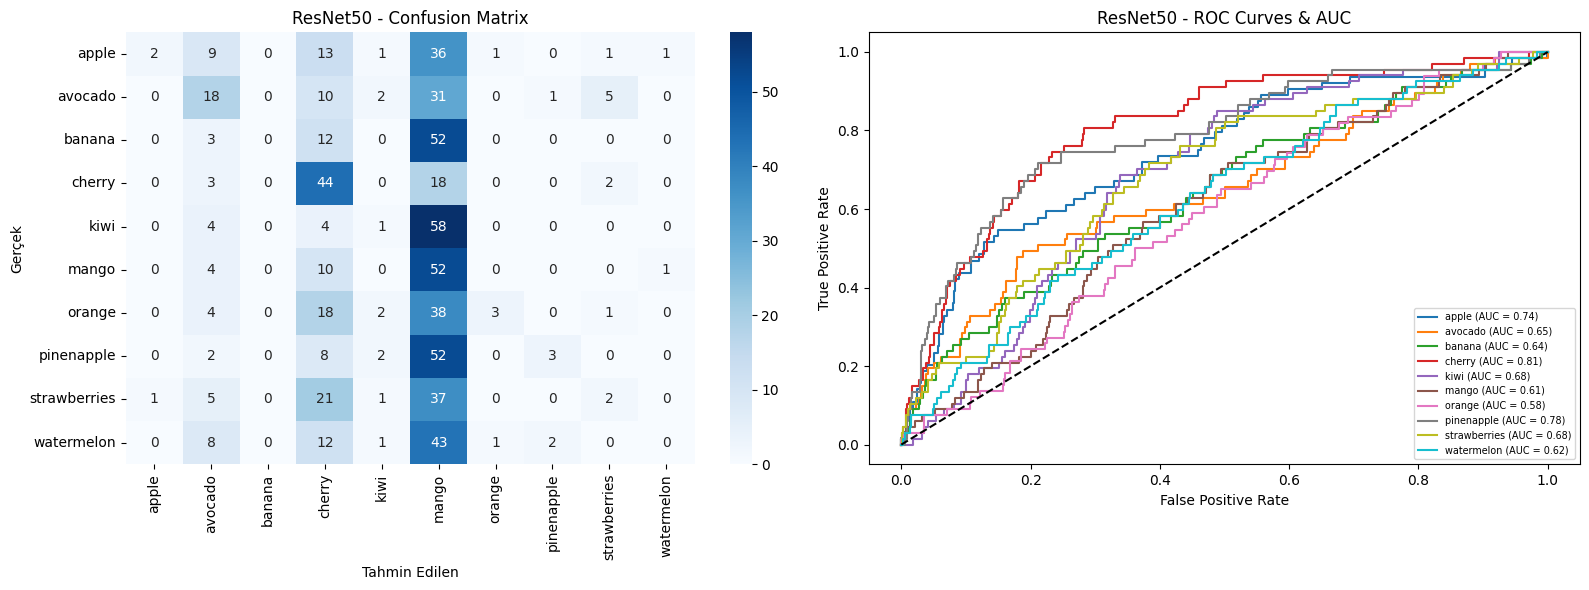


ResNet50 Performans Metrikleri:
        Sınıf  Sensitivity  Specificity  F1-Score  Precision
       apple     0.031250     0.998339  0.059701   0.666667
     avocado     0.268657     0.929883  0.283465   0.300000
      banana     0.000000     1.000000  0.000000   0.000000
      cherry     0.656716     0.819699  0.401826   0.289474
        kiwi     0.014925     0.984975  0.025974   0.100000
       mango     0.776119     0.390651  0.214876   0.124700
      orange     0.045455     0.996667  0.084507   0.600000
  pinenapple     0.044776     0.994992  0.082192   0.500000
strawberries     0.029851     0.984975  0.051282   0.181818
  watermelon     0.000000     0.996661  0.000000   0.000000


##################################################
# MODEL: VGG16 EĞİTİMİ BAŞLIYOR
##################################################
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 291ms/step - accuracy: 0.4372 - loss: 1.5952 - val_accuracy: 0.7027 - val_loss: 0.8574
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 18s

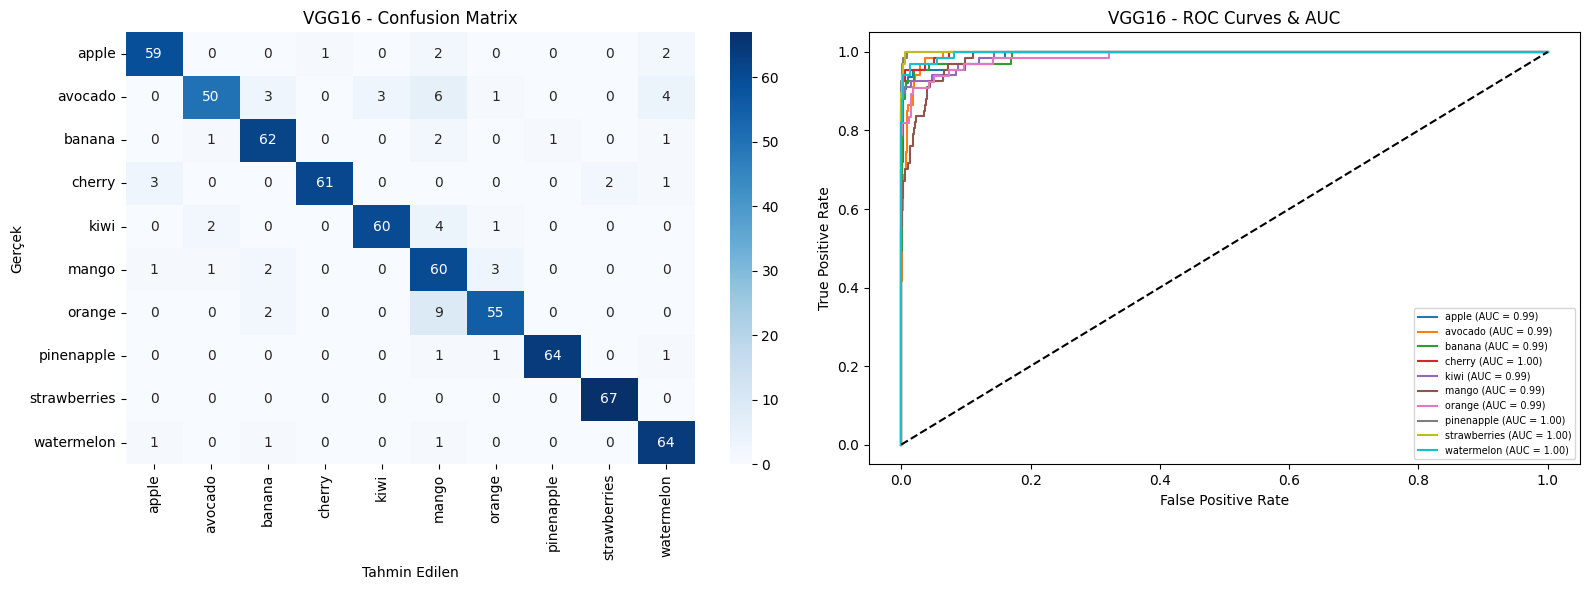


VGG16 Performans Metrikleri:
        Sınıf  Sensitivity  Specificity  F1-Score  Precision
       apple     0.921875     0.991694  0.921875   0.921875
     avocado     0.746269     0.993322  0.826446   0.925926
      banana     0.925373     0.986644  0.905109   0.885714
      cherry     0.910448     0.998331  0.945736   0.983871
        kiwi     0.895522     0.994992  0.923077   0.952381
       mango     0.895522     0.958264  0.789474   0.705882
      orange     0.833333     0.990000  0.866142   0.901639
  pinenapple     0.955224     0.998331  0.969697   0.984615
strawberries     1.000000     0.996661  0.985294   0.971014
  watermelon     0.955224     0.984975  0.914286   0.876712


##################################################
# MODEL: InceptionV3 EĞİTİMİ BAŞLIYOR
##################################################
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 33s 244ms/step - accuracy: 0.3797 - loss: 2.0151 - val_accuracy: 0.6066 - val_loss: 1.1898
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 

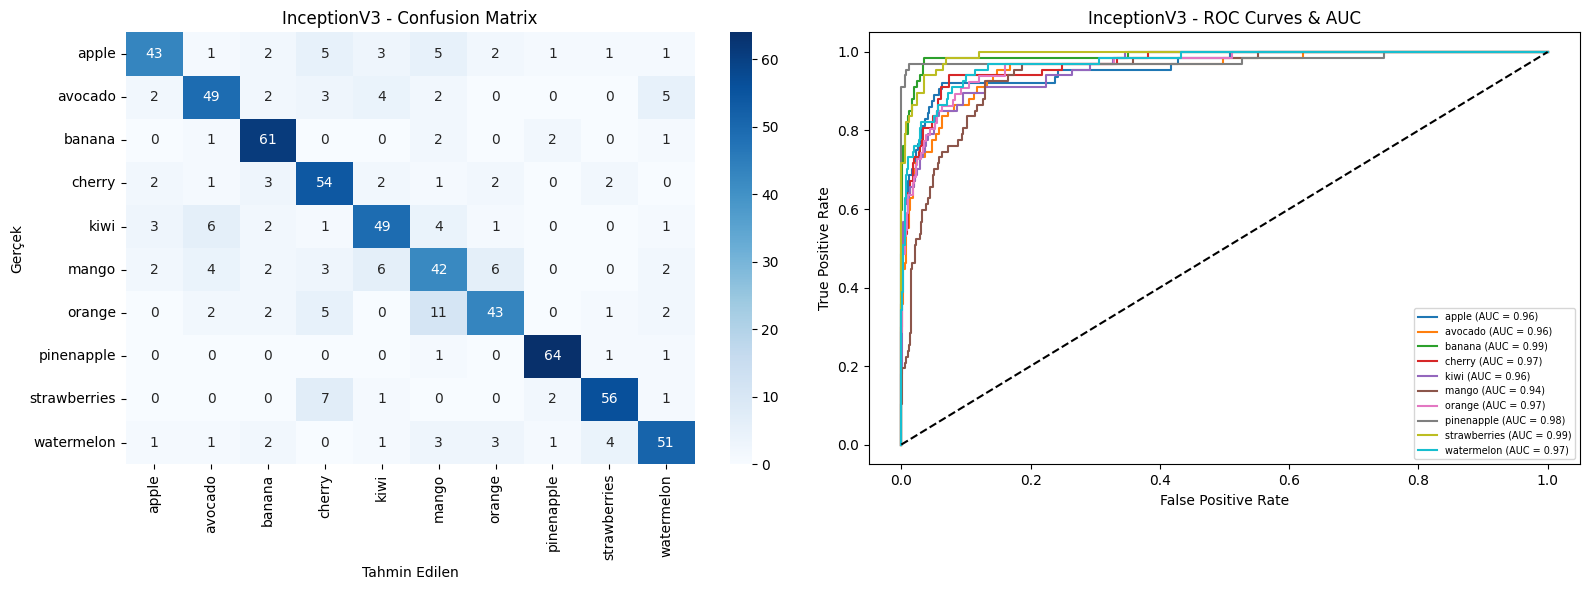


InceptionV3 Performans Metrikleri:
        Sınıf  Sensitivity  Specificity  F1-Score  Precision
       apple     0.671875     0.983389  0.735043   0.811321
     avocado     0.731343     0.973289  0.742424   0.753846
      banana     0.910448     0.974958  0.853147   0.802632
      cherry     0.805970     0.959933  0.744828   0.692308
        kiwi     0.731343     0.971619  0.736842   0.742424
       mango     0.626866     0.951586  0.608696   0.591549
      orange     0.651515     0.976667  0.699187   0.754386
  pinenapple     0.955224     0.989983  0.934307   0.914286
strawberries     0.835821     0.984975  0.848485   0.861538
  watermelon     0.761194     0.976628  0.772727   0.784615


In [ ]:
def plot_and_report(model, name, val_gen, categories):
    y_true = val_gen.classes
    y_pred_prob = model.predict(val_gen, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # A. Konfüzyon Matrisi
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories, ax=ax1)
    ax1.set_title(f'{name} - Confusion Matrix')
    ax1.set_xlabel('Tahmin Edilen')
    ax1.set_ylabel('Gerçek')

    # B. ROC Eğrileri ve AUC
    y_true_bin = label_binarize(y_true, classes=range(len(categories)))
    for i in range(len(categories)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax2.plot(fpr, tpr, label=f'{categories[i]} (AUC = {roc_auc:.2f})')

    ax2.plot([0, 1], [0, 1], 'k--')
    ax2.set_title(f'{name} - ROC Curves & AUC')
    ax2.set_xlabel('False Positive Rate')
    ax2.set_ylabel('True Positive Rate')
    ax2.legend(loc='lower right', fontsize='x-small')

    plt.tight_layout()
    plt.show()

    # C. Metrik Tablosu
    results = []
    for i in range(len(categories)):
        tp = cm[i, i]; fp = cm[:, i].sum() - tp; fn = cm[i, :].sum() - tp; tn = cm.sum() - (tp + fp + fn)
        sen = tp / (tp + fn) if (tp + fn) > 0 else 0
        spe = tn / (tn + fp) if (tn + fp) > 0 else 0
        pre = tp / (tp + fp) if (tp + fp) > 0 else 0
        f1 = 2*(pre*sen)/(pre+sen) if (pre+sen) > 0 else 0
        results.append([categories[i], sen, spe, f1, pre])

    met_df = pd.DataFrame(results, columns=['Sınıf', 'Sensitivity', 'Specificity', 'F1-Score', 'Precision'])
    print(f"\n{name} Performans Metrikleri:\n", met_df.to_string(index=False))

# --- 3. MODEL DÖNGÜSÜ ---
models_to_test = {
    "MobileNetV2": MobileNetV2,
    "EfficientNetB0": EfficientNetB0,
    "ResNet50": ResNet50,
    "VGG16": VGG16,
    "InceptionV3": InceptionV3
}

for name, model_func in models_to_test.items():
    print(f"\n\n{'#'*50}\n# MODEL: {name} EĞİTİMİ BAŞLIYOR\n{'#'*50}")

    base = model_func(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base.trainable = True
    for layer in base.layers[:-20]: base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(len(categories), activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(train_gen, epochs=EPOCHS, validation_data=val_gen, verbose=1)

    # Analiz ve Çizim
    plot_and_report(model, name, val_gen, categories)


    del model, base
    gc.collect()
    tf.keras.backend.clear_session()